# Flight-Only SOH Forecast Prep (Filtered)

This notebook prepares SOH for forecasting by:

- using discharge (flight) events only for the forecasting view
- separating charging events into their own plot
- removing large positive SOH spikes (>5%) relative to a moving average
- plotting SOH relative to multiple cumulative x-axes (Ah, kWh, EFC)
- checking if spikes align with SOC operating bands (e.g., 30–80%)


In [28]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds

try:
    import yaml
except ImportError:  # pragma: no cover - optional dependency
    yaml = None


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'ml_workspace').exists() and (candidate / 'data').exists():
            return candidate
    raise RuntimeError('Could not locate project root from notebook working directory.')


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 200)


## Configuration

Adjust the planes list or the moving average window as needed. The spike filter removes positive SOH jumps greater than 5% relative to the moving average.


In [29]:
TIMESERIES_PATH = PROJECT_ROOT / 'data' / 'event_timeseries.parquet'
BATTERY_SPECS_PATH = PROJECT_ROOT / 'ml_workspace' / 'battery_specs.yaml'

PLANES = ['166', '192']

MOVING_AVG_WINDOW = 11
SPIKE_THRESHOLD_PCT = 5.0

RATED_CAPACITY_KEY = 'c23_discharge_20a'
DEFAULT_RATED_CAPACITY_AH = 29.0
DEFAULT_RATED_ENERGY_KWH = 10.0

SOC_BIN_EDGES = list(range(0, 101, 10))


## Build An Event-Level Observed SOH Table

We aggregate each event to one SOH value per battery and carry the event-type flags so we can separate flight (discharge) events from charging events. We estimate per-event charge/discharge Ah and kWh from the current + voltage trace, and capture SOC range per event.


In [30]:
def load_rated_capacity_map(path: Path, key: str) -> tuple[dict[str, float], dict[str, float]]:
    if yaml is None or not path.exists():
        return {}, {}
    data = yaml.safe_load(path.read_text()) or {}
    planes = data.get('planes', {})
    cap_map = {}
    energy_map = {}
    for plane_id, info in planes.items():
        rated = info.get('rated_capacity', {}).get(key, {})
        cap = rated.get('capacity_ah')
        energy = rated.get('energy_kwh')
        if cap is not None:
            cap_map[str(plane_id)] = float(cap)
        if energy is not None:
            energy_map[str(plane_id)] = float(energy)
    return cap_map, energy_map


def load_event_level_observed_soh(timeseries_path: Path, planes: list[str]) -> pd.DataFrame:
    dataset = ds.dataset(str(timeseries_path), format='parquet')
    pack_frames = []
    for pack_id in (1, 2):
        p = str(pack_id)
        cols = [
            'plane_id',
            'flight_id',
            'event_datetime',
            'is_flight_event',
            'is_charging_event',
            'source_csv_kind',
            'source_pack_id',
            'time_ms',
            f' bat {p} soh',
            f' bat {p} avg cell temp',
            f' bat {p} current',
            f' bat {p} voltage',
            f' bat {p} soc',
        ]
        table = dataset.to_table(
            columns=cols,
            filter=(
                ds.field('plane_id').isin(planes)
                & (ds.field('source_csv_kind') == 'aux')
                & (ds.field('source_pack_id') == pack_id)
            ),
        )
        frame = table.to_pandas().rename(
            columns={
                f' bat {p} soh': 'observed_soh_pct',
                f' bat {p} avg cell temp': 'avg_cell_temp_c',
                f' bat {p} current': 'current_a',
                f' bat {p} voltage': 'voltage_v',
                f' bat {p} soc': 'soc_pct',
            }
        )
        frame['battery_id'] = pack_id
        pack_frames.append(frame)

    raw = pd.concat(pack_frames, ignore_index=True)
    raw['event_datetime'] = pd.to_datetime(raw['event_datetime'], errors='coerce')
    raw['observed_soh_pct'] = pd.to_numeric(raw['observed_soh_pct'], errors='coerce')
    raw['time_ms'] = pd.to_numeric(raw['time_ms'], errors='coerce')
    raw['avg_cell_temp_c'] = pd.to_numeric(raw['avg_cell_temp_c'], errors='coerce')
    raw['current_a'] = pd.to_numeric(raw['current_a'], errors='coerce').fillna(0.0)
    raw['voltage_v'] = pd.to_numeric(raw['voltage_v'], errors='coerce').fillna(0.0)
    raw['soc_pct'] = pd.to_numeric(raw['soc_pct'], errors='coerce')
    raw = raw.dropna(subset=['event_datetime', 'observed_soh_pct'])

    raw = raw.sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id', 'time_ms'])
    raw['dt_s'] = (
        raw.groupby(['plane_id', 'flight_id', 'event_datetime', 'battery_id'])['time_ms']
        .diff()
        .div(1000.0)
        .fillna(0.0)
        .clip(lower=0.0)
    )

    raw['discharge_current_a'] = raw['current_a'].clip(lower=0.0)
    raw['charge_current_a'] = (-raw['current_a']).clip(lower=0.0)
    raw['discharge_ah_step'] = raw['discharge_current_a'] * raw['dt_s'] / 3600.0
    raw['charge_ah_step'] = raw['charge_current_a'] * raw['dt_s'] / 3600.0

    raw['discharge_kwh_step'] = raw['discharge_current_a'] * raw['voltage_v'] * raw['dt_s'] / 3600.0 / 1000.0
    raw['charge_kwh_step'] = raw['charge_current_a'] * raw['voltage_v'] * raw['dt_s'] / 3600.0 / 1000.0

    event_df = raw.groupby(['plane_id', 'flight_id', 'event_datetime', 'battery_id'], as_index=False).agg(
        observed_soh_pct=('observed_soh_pct', 'median'),
        observed_soh_iqr_pct=(
            'observed_soh_pct',
            lambda s: pd.to_numeric(s, errors='coerce').quantile(0.75)
            - pd.to_numeric(s, errors='coerce').quantile(0.25),
        ),
        avg_cell_temp_c=('avg_cell_temp_c', 'mean'),
        soc_mean_pct=('soc_pct', 'mean'),
        soc_min_pct=('soc_pct', 'min'),
        soc_max_pct=('soc_pct', 'max'),
        event_discharge_ah=('discharge_ah_step', 'sum'),
        event_charge_ah=('charge_ah_step', 'sum'),
        event_discharge_kwh=('discharge_kwh_step', 'sum'),
        event_charge_kwh=('charge_kwh_step', 'sum'),
        time_ms_min=('time_ms', 'min'),
        time_ms_max=('time_ms', 'max'),
        is_flight_event=('is_flight_event', 'max'),
        is_charging_event=('is_charging_event', 'max'),
    )
    event_df['soc_span_pct'] = event_df['soc_max_pct'] - event_df['soc_min_pct']
    event_df['event_throughput_ah'] = event_df['event_discharge_ah'].fillna(0.0) + event_df['event_charge_ah'].fillna(0.0)
    event_df['event_throughput_kwh'] = event_df['event_discharge_kwh'].fillna(0.0) + event_df['event_charge_kwh'].fillna(0.0)
    event_df['event_duration_min'] = ((event_df['time_ms_max'] - event_df['time_ms_min']) / 60000.0).clip(lower=0.0)
    event_df['event_type'] = np.where(
        event_df['is_flight_event'] == 1,
        'flight',
        np.where(event_df['is_charging_event'] == 1, 'charge', 'other'),
    )
    event_df = event_df.sort_values(['plane_id', 'battery_id', 'event_datetime', 'flight_id']).reset_index(drop=True)
    event_df['event_index'] = event_df.groupby(['plane_id', 'battery_id']).cumcount() + 1
    return event_df


## Flight-Only SOH With Positive-Spike Filtering

We compute a moving average on flight events, flag positive SOH spikes (>5% above the moving average), and remove those spikes from the forecasting view. We also compute multiple cumulative x-axes (Ah, kWh, EFC).


In [31]:
def add_ma_and_spike_flags(group: pd.DataFrame) -> pd.DataFrame:
    g = group.sort_values(['event_datetime', 'flight_id']).reset_index(drop=True).copy()
    g['flight_event_index'] = np.arange(1, len(g) + 1)
    soh = pd.to_numeric(g['observed_soh_pct'], errors='coerce')
    g['soh_ma_raw'] = soh.rolling(MOVING_AVG_WINDOW, center=True, min_periods=1).mean()
    ma = g['soh_ma_raw'].to_numpy(dtype=float)
    g['soh_ma_pct_delta'] = np.where(ma > 0, (soh - ma) / ma * 100.0, np.nan)
    g['is_positive_spike'] = g['soh_ma_pct_delta'] > SPIKE_THRESHOLD_PCT
    return g


def add_filtered_ma(group: pd.DataFrame) -> pd.DataFrame:
    g = group.sort_values(['event_datetime', 'flight_id']).reset_index(drop=True).copy()
    g['flight_event_index'] = np.arange(1, len(g) + 1)
    soh = pd.to_numeric(g['observed_soh_pct'], errors='coerce')
    g['soh_ma_filtered'] = soh.rolling(MOVING_AVG_WINDOW, center=True, min_periods=1).mean()
    return g


def add_cumulative_metrics(group: pd.DataFrame) -> pd.DataFrame:
    g = group.sort_values(['event_datetime', 'flight_id']).reset_index(drop=True).copy()
    g['cumulative_discharge_ah'] = pd.to_numeric(g['event_discharge_ah'], errors='coerce').fillna(0.0).cumsum()
    g['cumulative_charge_ah'] = pd.to_numeric(g['event_charge_ah'], errors='coerce').fillna(0.0).cumsum()
    g['cumulative_throughput_ah'] = pd.to_numeric(g['event_throughput_ah'], errors='coerce').fillna(0.0).cumsum()
    g['cumulative_discharge_kwh'] = pd.to_numeric(g['event_discharge_kwh'], errors='coerce').fillna(0.0).cumsum()
    g['cumulative_charge_kwh'] = pd.to_numeric(g['event_charge_kwh'], errors='coerce').fillna(0.0).cumsum()
    g['cumulative_throughput_kwh'] = pd.to_numeric(g['event_throughput_kwh'], errors='coerce').fillna(0.0).cumsum()

    g['cumulative_efc_ah'] = np.where(
        g['rated_capacity_ah'] > 0,
        g['cumulative_throughput_ah'] / (2.0 * g['rated_capacity_ah']),
        np.nan,
    )
    g['cumulative_efc_kwh'] = np.where(
        g['rated_energy_kwh'] > 0,
        g['cumulative_throughput_kwh'] / (2.0 * g['rated_energy_kwh']),
        np.nan,
    )
    return g


def apply_rated_capacity(df: pd.DataFrame) -> pd.DataFrame:
    cap_map, energy_map = load_rated_capacity_map(BATTERY_SPECS_PATH, RATED_CAPACITY_KEY)
    out = df.copy()
    out['rated_capacity_ah'] = out['plane_id'].map(cap_map).fillna(DEFAULT_RATED_CAPACITY_AH)
    out['rated_energy_kwh'] = out['plane_id'].map(energy_map).fillna(DEFAULT_RATED_ENERGY_KWH)
    return out


event_df = load_event_level_observed_soh(TIMESERIES_PATH, PLANES)
event_df = apply_rated_capacity(event_df)
event_df = pd.concat(
    [add_cumulative_metrics(g) for _, g in event_df.groupby(['plane_id', 'battery_id'], sort=True)],
    ignore_index=True,
)

flight_df = event_df.loc[event_df['event_type'] == 'flight'].copy()
charge_df = event_df.loc[event_df['event_type'] == 'charge'].copy()

flight_with_ma = pd.concat(
    [add_ma_and_spike_flags(g) for _, g in flight_df.groupby(['plane_id', 'battery_id'], sort=True)],
    ignore_index=True,
)

flight_filtered = flight_with_ma.loc[~flight_with_ma['is_positive_spike']].copy()
flight_filtered = pd.concat(
    [add_filtered_ma(g) for _, g in flight_filtered.groupby(['plane_id', 'battery_id'], sort=True)],
    ignore_index=True,
)

summary = flight_with_ma.groupby(['plane_id', 'battery_id'], as_index=False).agg(
    n_flight_events=('flight_id', 'count'),
    n_spike_removed=('is_positive_spike', 'sum'),
    total_discharge_ah=('event_discharge_ah', 'sum'),
    total_charge_ah=('event_charge_ah', 'sum'),
    total_throughput_ah=('event_throughput_ah', 'sum'),
    total_throughput_kwh=('event_throughput_kwh', 'sum'),
)
summary['spike_share_pct'] = (summary['n_spike_removed'] / summary['n_flight_events'] * 100.0).round(2)
summary


,plane_id,battery_id,n_flight_events,n_spike_removed,total_discharge_ah,total_charge_ah,total_throughput_ah,total_throughput_kwh,spike_share_pct
0,166,1,194,17,3425.384491,567.989870,3993.374362,6231.458089,8.76
1,166,2,194,14,3440.628723,721.533208,4162.161931,6952.029899,7.22
2,192,1,20,0,300.078018,15.353436,315.431454,114.891159,0.00
3,192,2,20,0,299.114613,15.259511,314.374125,114.457630,0.00


## Flight-Only SOH vs Multiple X-Axes

Each plot uses the same filtered flight-only SOH points but changes the x-axis to a cumulative usage metric. This helps identify which axis best spreads high-usage spikes and yields stable trends for forecasting.


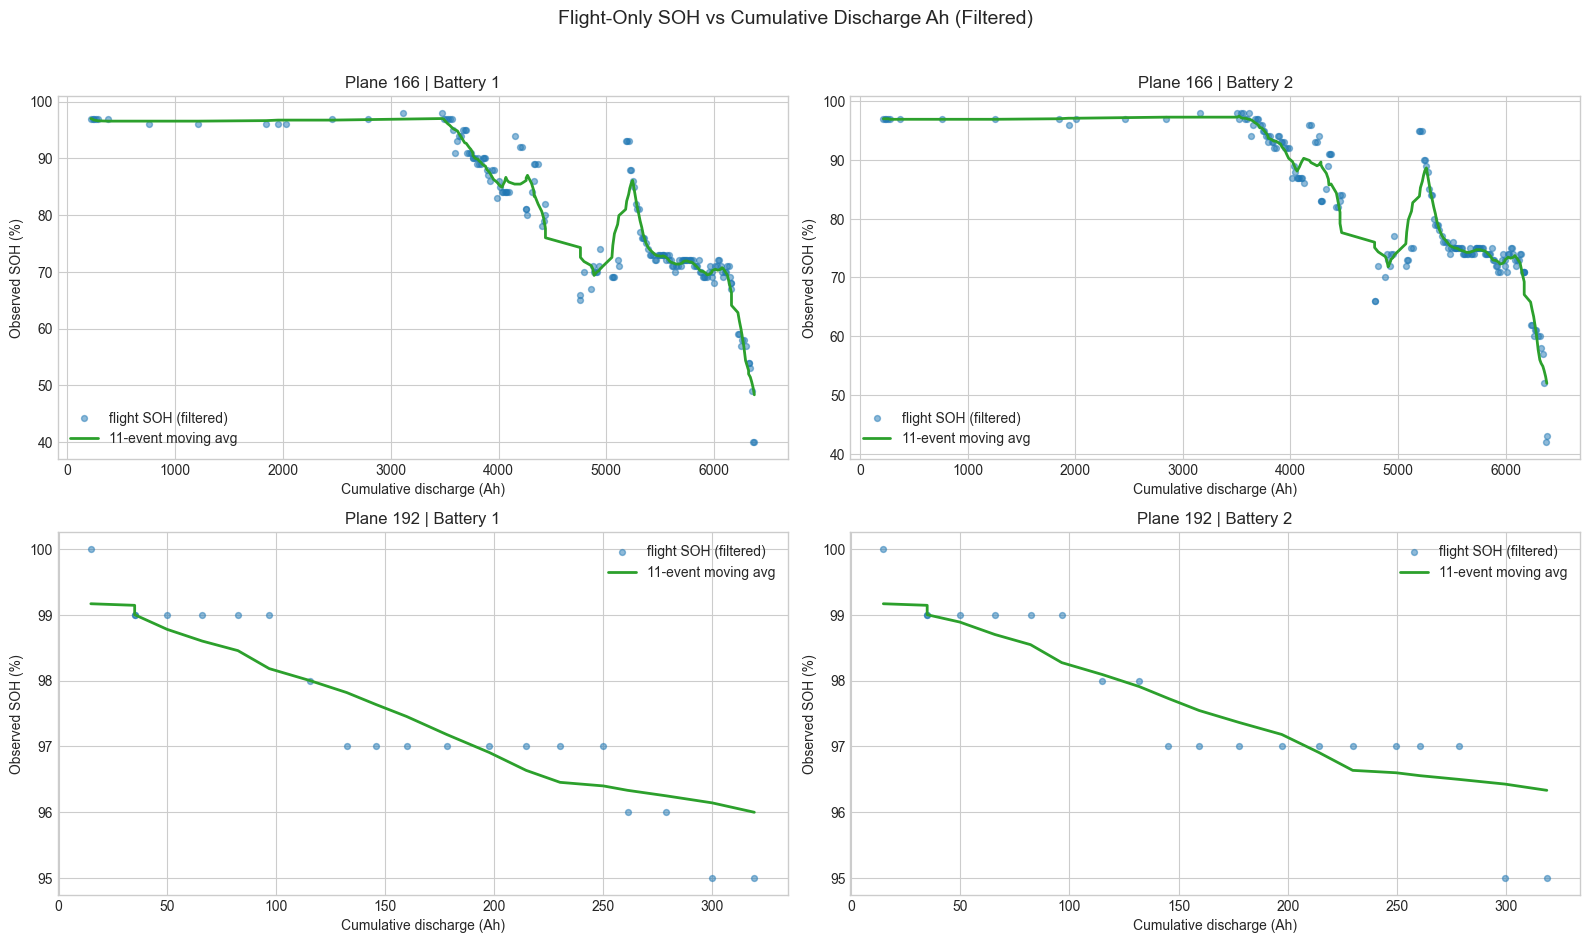

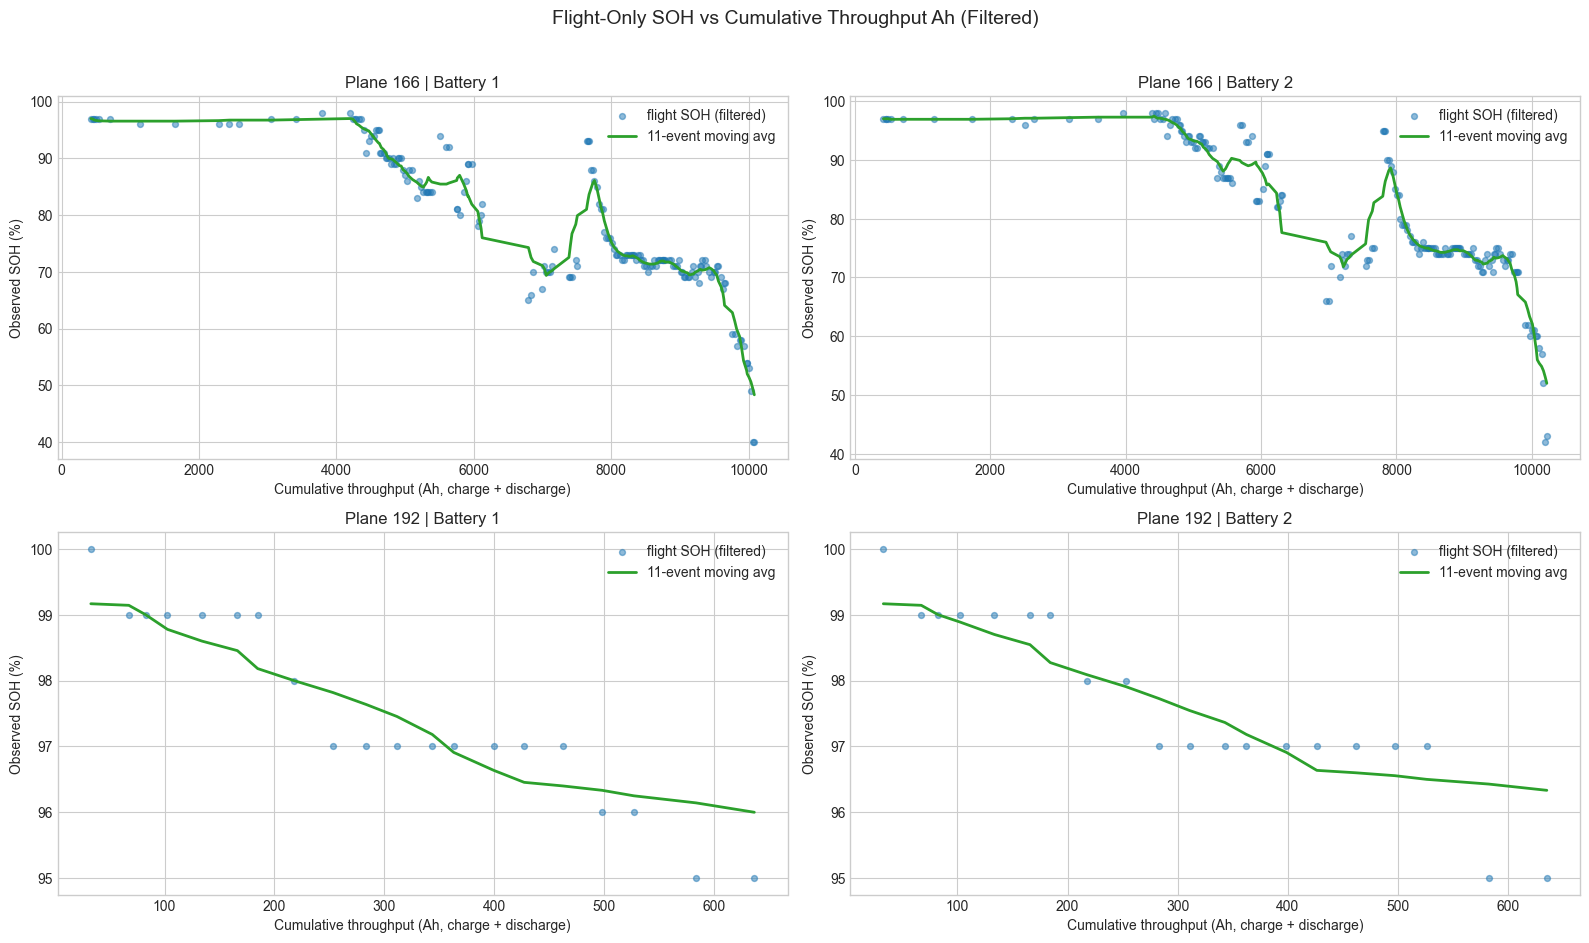

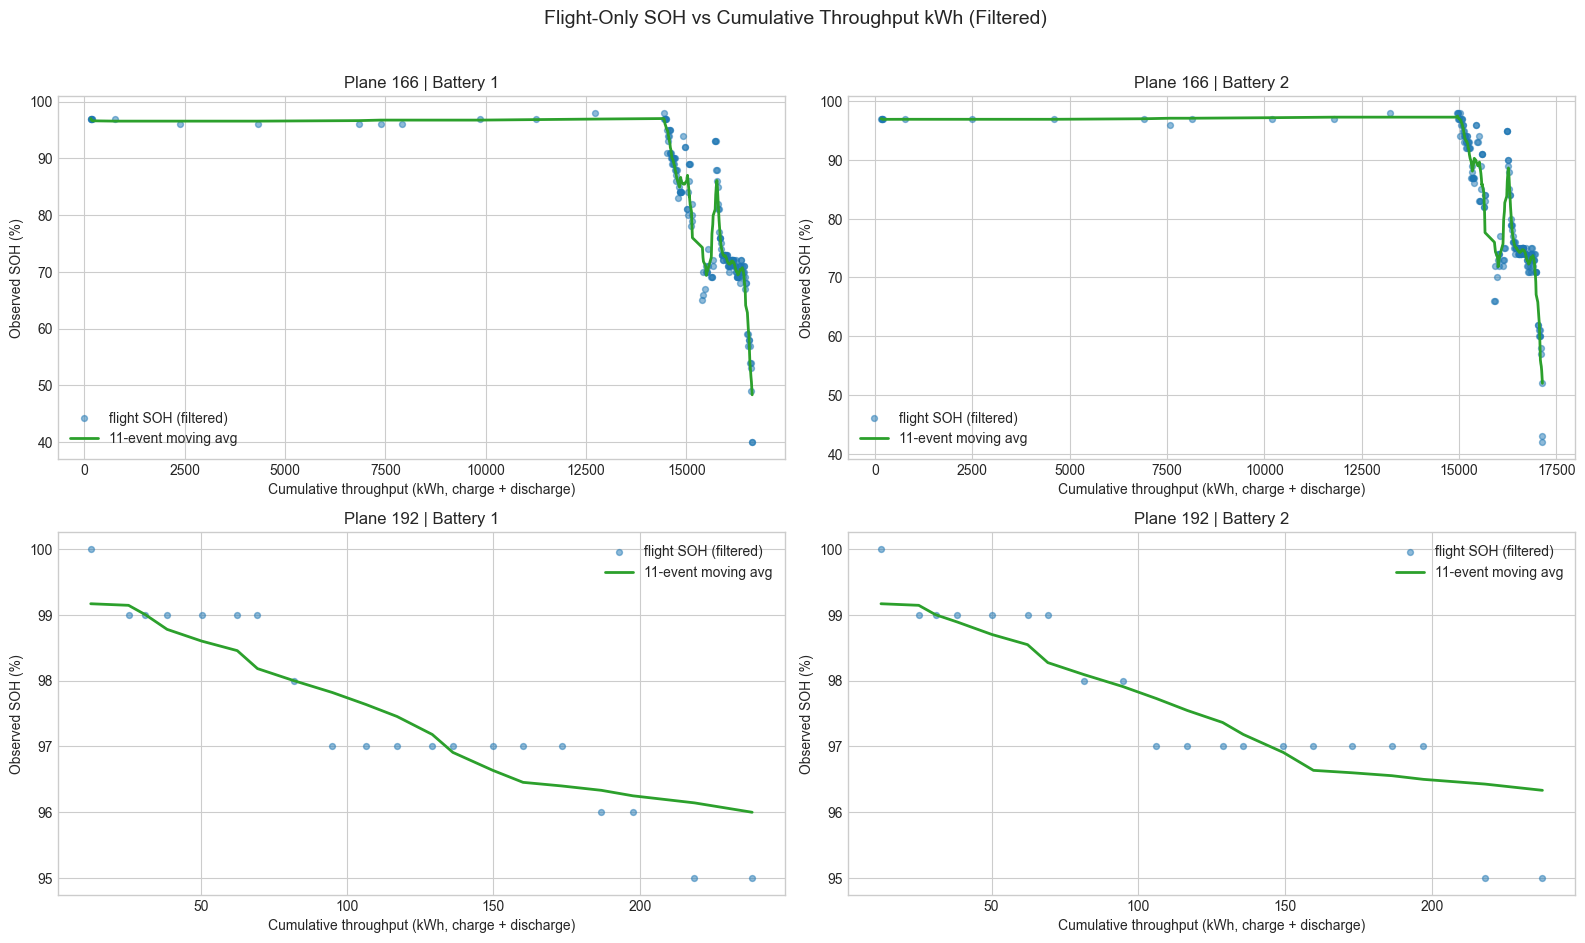

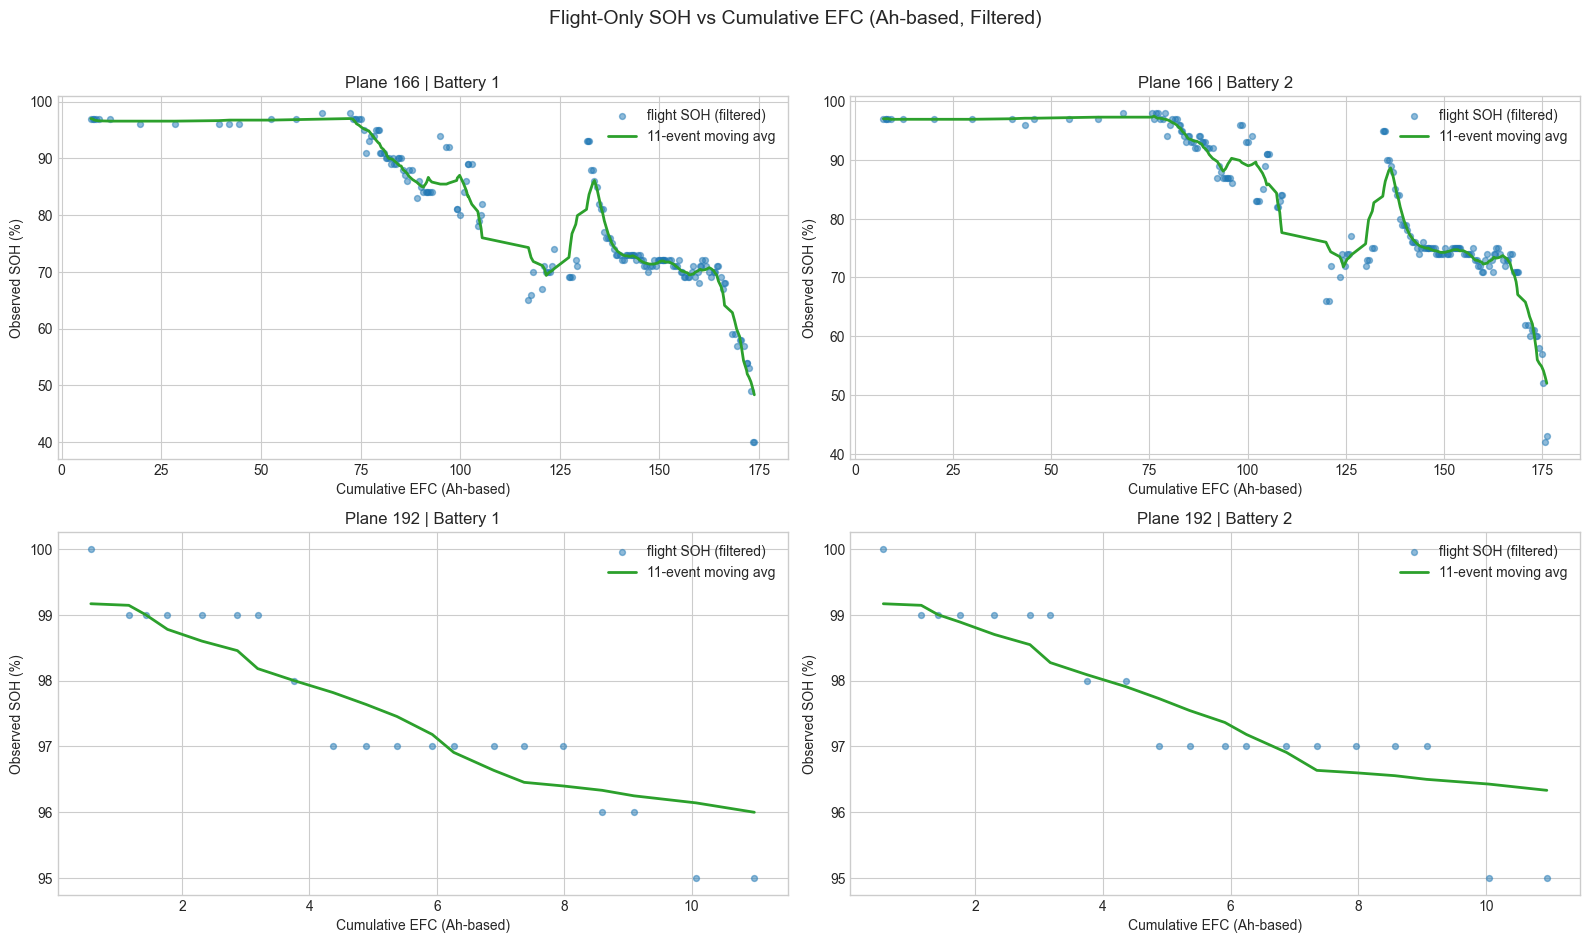

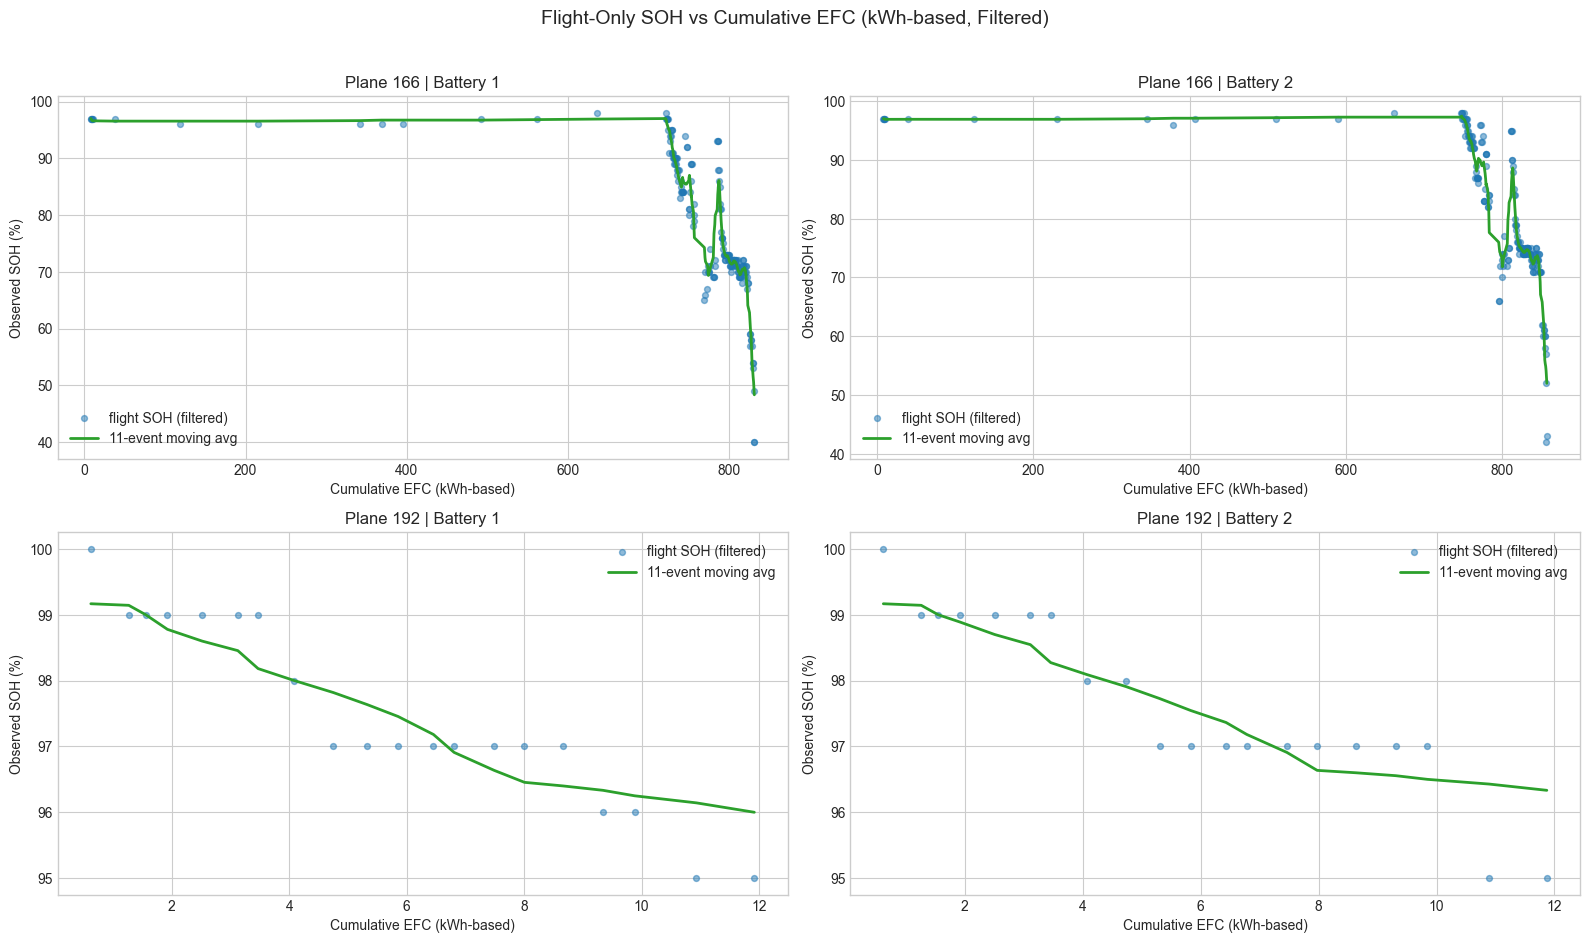

In [32]:
def plot_soh_vs_x(df: pd.DataFrame, x_col: str, x_label: str, title: str) -> None:
    planes = sorted(df['plane_id'].unique())
    fig, axes = plt.subplots(len(planes), 2, figsize=(16, 4.6 * len(planes)), sharex=False, sharey=False)
    axes = np.atleast_2d(axes)

    for row, plane_id in enumerate(planes):
        for col, battery_id in enumerate([1, 2]):
            ax = axes[row, col]
            g = df[(df['plane_id'] == plane_id) & (df['battery_id'] == battery_id)].copy()
            if g.empty:
                ax.set_visible(False)
                continue

            ax.scatter(
                g[x_col],
                g['observed_soh_pct'],
                s=18,
                alpha=0.5,
                color='#1f77b4',
                label='flight SOH (filtered)',
            )
            ax.plot(
                g[x_col],
                g['soh_ma_filtered'],
                color='#2ca02c',
                linewidth=2.0,
                label=f'{MOVING_AVG_WINDOW}-event moving avg',
            )
            ax.set_title(f'Plane {plane_id} | Battery {battery_id}')
            ax.set_xlabel(x_label)
            ax.set_ylabel('Observed SOH (%)')
            ax.legend(loc='best')

    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_soh_vs_x(
    flight_filtered,
    'cumulative_discharge_ah',
    'Cumulative discharge (Ah)',
    'Flight-Only SOH vs Cumulative Discharge Ah (Filtered)',
)
plot_soh_vs_x(
    flight_filtered,
    'cumulative_throughput_ah',
    'Cumulative throughput (Ah, charge + discharge)',
    'Flight-Only SOH vs Cumulative Throughput Ah (Filtered)',
)
plot_soh_vs_x(
    flight_filtered,
    'cumulative_throughput_kwh',
    'Cumulative throughput (kWh, charge + discharge)',
    'Flight-Only SOH vs Cumulative Throughput kWh (Filtered)',
)
plot_soh_vs_x(
    flight_filtered,
    'cumulative_efc_ah',
    'Cumulative EFC (Ah-based)',
    'Flight-Only SOH vs Cumulative EFC (Ah-based, Filtered)',
)
plot_soh_vs_x(
    flight_filtered,
    'cumulative_efc_kwh',
    'Cumulative EFC (kWh-based)',
    'Flight-Only SOH vs Cumulative EFC (kWh-based, Filtered)',
)


## SOC Band Diagnostics (Do Spikes Cluster By SOC Window?)

These plots highlight whether positive SOH spikes tend to occur at specific SOC ranges or depth-of-discharge windows.


<>:8: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\)'
<>:13: SyntaxWarning: invalid escape sequence '\['
<>:14: SyntaxWarning: invalid escape sequence '\)'
<>:8: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\)'
<>:13: SyntaxWarning: invalid escape sequence '\['
<>:14: SyntaxWarning: invalid escape sequence '\)'
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_27006/2606049713.py:8: SyntaxWarning: invalid escape sequence '\['
  .str.replace('\[', '', regex=True)
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_27006/2606049713.py:9: SyntaxWarning: invalid escape sequence '\)'
  .str.replace('\)', '', regex=True)
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_27006/2606049713.py:13: SyntaxWarning: invalid escape sequence '\['
  .str.replace('\[', '', regex=True)
/var/folders/gc/2hjqw94d0fg3h32mgnj49r7m0000gn/T/ipykernel_27006/2606049713.py:14: SyntaxWarning: invalid 

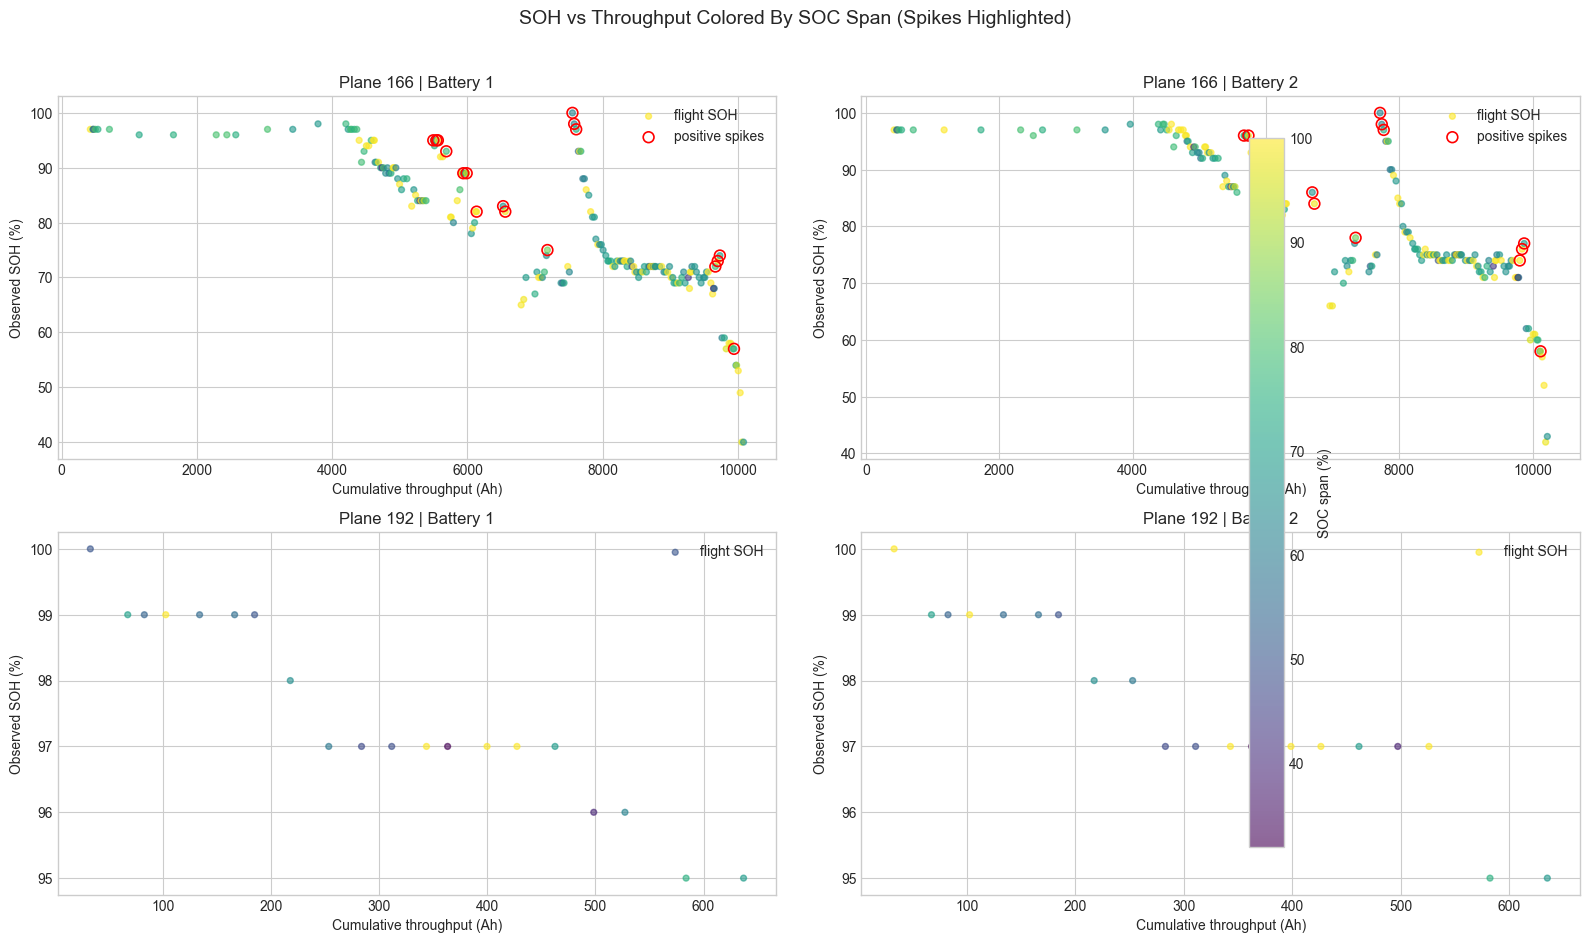

In [37]:
def add_soc_bins(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['soc_min_bin'] = pd.cut(out['soc_min_pct'], SOC_BIN_EDGES, right=False)
    out['soc_max_bin'] = pd.cut(out['soc_max_pct'], SOC_BIN_EDGES, right=False)
    out['soc_span_bin'] = pd.cut(out['soc_span_pct'], SOC_BIN_EDGES, right=False)
    out['soc_window_label'] = (
        out['soc_min_bin'].astype(str)
        .str.replace('\[', '', regex=True)
        .str.replace('\)', '', regex=True)
        .str.replace(', ', '-', regex=True)
        + ' to '
        + out['soc_max_bin'].astype(str)
        .str.replace('\[', '', regex=True)
        .str.replace('\)', '', regex=True)
        .str.replace(', ', '-', regex=True)
    )
    return out


flight_with_soc = add_soc_bins(flight_with_ma)

# 1) Scatter: SOH vs throughput, color by SOC span, spikes highlighted
planes = sorted(flight_with_soc['plane_id'].unique())
fig, axes = plt.subplots(len(planes), 2, figsize=(16, 4.6 * len(planes)), sharex=False, sharey=False)
axes = np.atleast_2d(axes)

for row, plane_id in enumerate(planes):
    for col, battery_id in enumerate([1, 2]):
        ax = axes[row, col]
        g = flight_with_soc[(flight_with_soc['plane_id'] == plane_id) & (flight_with_soc['battery_id'] == battery_id)].copy()
        if g.empty:
            ax.set_visible(False)
            continue

        sc = ax.scatter(
            g['cumulative_throughput_ah'],
            g['observed_soh_pct'],
            c=g['soc_span_pct'],
            cmap='viridis',
            s=18,
            alpha=0.6,
            label='flight SOH',
        )
        spikes = g[g['is_positive_spike']]
        if not spikes.empty:
            ax.scatter(
                spikes['cumulative_throughput_ah'],
                spikes['observed_soh_pct'],
                facecolors='none',
                edgecolors='red',
                s=60,
                linewidths=1.2,
                label='positive spikes',
            )
        ax.set_title(f'Plane {plane_id} | Battery {battery_id}')
        ax.set_xlabel('Cumulative throughput (Ah)')
        ax.set_ylabel('Observed SOH (%)')
        ax.legend(loc='best')

fig.suptitle('SOH vs Throughput Colored By SOC Span (Spikes Highlighted)', fontsize=14, y=1.02)
fig.colorbar(sc, ax=axes.ravel().tolist(), label='SOC span (%)')
plt.tight_layout()
plt.show()


## All Events SOH vs Cumulative Throughput Ah

This view includes charging events alongside flights, but the filtering is still based on the flight-only moving average.


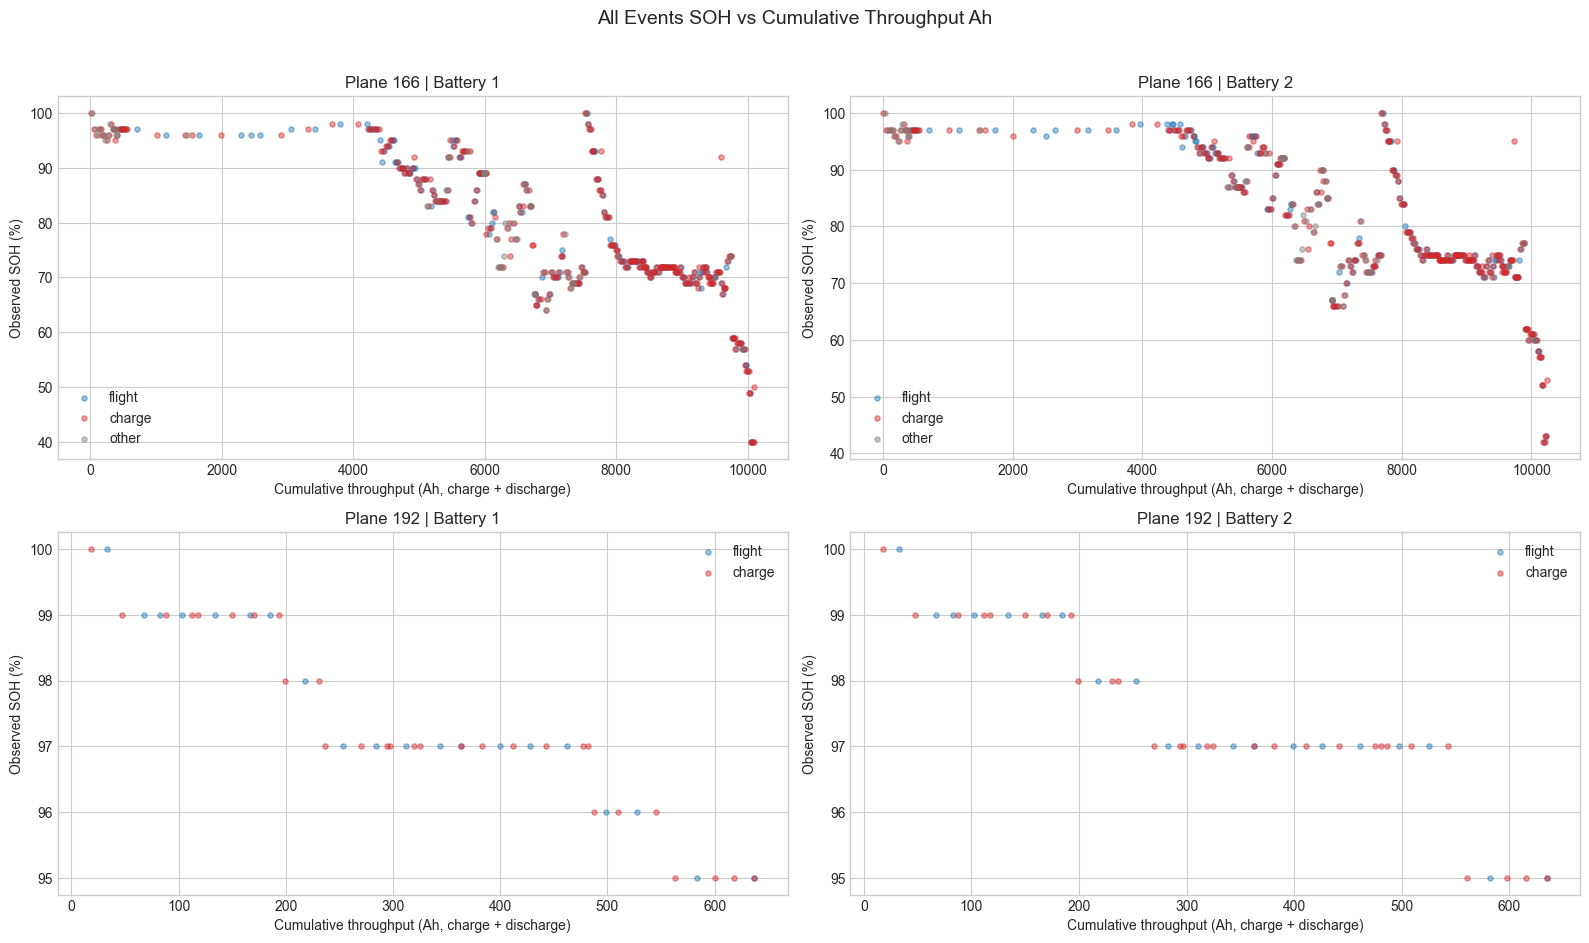

In [34]:
event_type_colors = {'flight': '#1f77b4', 'charge': '#d62728', 'other': '#7f7f7f'}

planes = sorted(event_df['plane_id'].unique())
fig, axes = plt.subplots(len(planes), 2, figsize=(16, 4.6 * len(planes)), sharex=False, sharey=False)
axes = np.atleast_2d(axes)

for row, plane_id in enumerate(planes):
    for col, battery_id in enumerate([1, 2]):
        ax = axes[row, col]
        g = event_df[(event_df['plane_id'] == plane_id) & (event_df['battery_id'] == battery_id)].copy()
        if g.empty:
            ax.set_visible(False)
            continue

        for event_type in ['flight', 'charge', 'other']:
            sub = g[g['event_type'] == event_type]
            if sub.empty:
                continue
            ax.scatter(
                sub['cumulative_throughput_ah'],
                sub['observed_soh_pct'],
                s=14,
                alpha=0.45,
                color=event_type_colors[event_type],
                label=event_type,
            )

        ax.set_title(f'Plane {plane_id} | Battery {battery_id}')
        ax.set_xlabel('Cumulative throughput (Ah, charge + discharge)')
        ax.set_ylabel('Observed SOH (%)')
        ax.legend(loc='best')

fig.suptitle('All Events SOH vs Cumulative Throughput Ah', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Correlations With SOH (Flight-Only, Filtered)

This table summarizes Pearson and Spearman correlations between SOH and each x-axis candidate.


In [35]:
def corr_table(df: pd.DataFrame, x_cols: list[str]) -> pd.DataFrame:
    rows = []
    for (plane_id, battery_id), g in df.groupby(['plane_id', 'battery_id'], sort=True):
        for x_col in x_cols:
            pair = g[[x_col, 'observed_soh_pct']].dropna()
            if len(pair) < 3:
                rows.append(
                    {
                        'plane_id': plane_id,
                        'battery_id': battery_id,
                        'x_col': x_col,
                        'n_points': len(pair),
                        'pearson': np.nan,
                        'spearman': np.nan,
                    }
                )
                continue
            pearson = pair[x_col].corr(pair['observed_soh_pct'], method='pearson')
            spearman = pair[x_col].corr(pair['observed_soh_pct'], method='spearman')
            rows.append(
                {
                    'plane_id': plane_id,
                    'battery_id': battery_id,
                    'x_col': x_col,
                    'n_points': len(pair),
                    'pearson': float(pearson),
                    'spearman': float(spearman),
                }
            )
    return pd.DataFrame(rows).sort_values(['plane_id', 'battery_id', 'x_col']).reset_index(drop=True)


x_candidates = [
    'cumulative_discharge_ah',
    'cumulative_throughput_ah',
    'cumulative_throughput_kwh',
    'cumulative_efc_ah',
    'cumulative_efc_kwh',
]

corr_table(flight_filtered, x_candidates)


,plane_id,battery_id,x_col,n_points,pearson,spearman
0,166,1,cumulative_discharge_ah,177,-0.812502,-0.878979
1,166,1,cumulative_efc_ah,177,-0.859751,-0.878979
2,166,1,cumulative_efc_kwh,177,-0.550378,-0.878979
3,166,1,cumulative_throughput_ah,177,-0.859751,-0.878979
4,166,1,cumulative_throughput_kwh,177,-0.550378,-0.878979
5,166,2,cumulative_discharge_ah,180,-0.789175,-0.885199
6,166,2,cumulative_efc_ah,180,-0.842062,-0.885199
7,166,2,cumulative_efc_kwh,180,-0.505740,-0.885199
8,166,2,cumulative_throughput_ah,180,-0.842062,-0.885199
9,166,2,cumulative_throughput_kwh,180,-0.505740,-0.885199


## Charging Events (Reported Separately)

Charging events are shown here for reference only. These are not used for forecasting because SOH can be misreported during calibration.


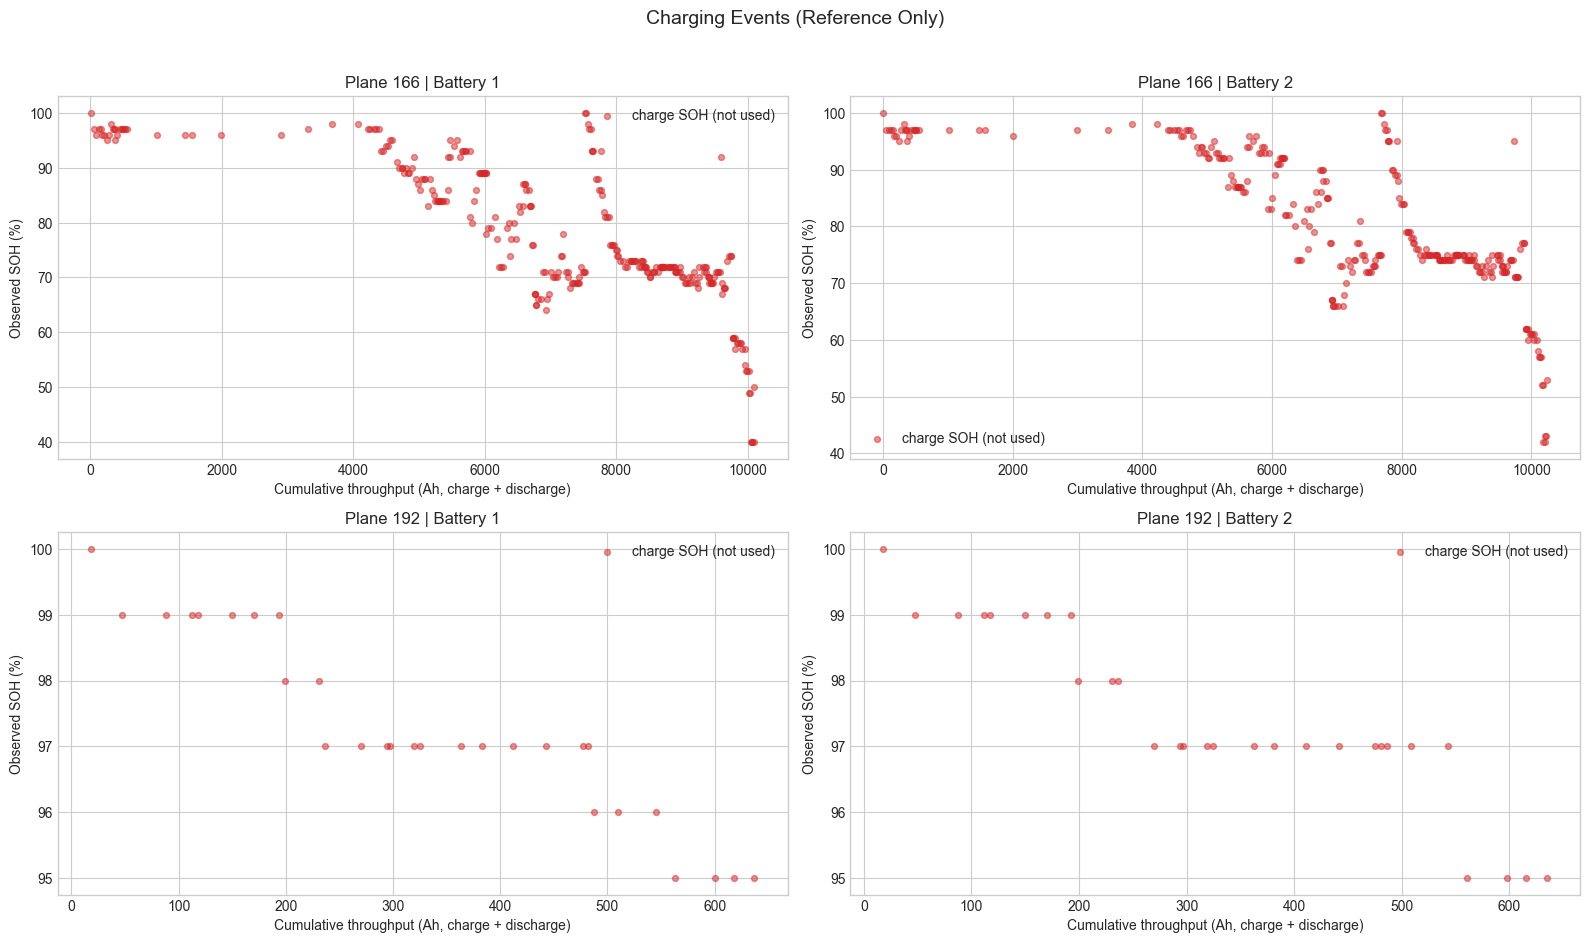

In [36]:
planes = sorted(charge_df['plane_id'].unique())
fig, axes = plt.subplots(len(planes), 2, figsize=(16, 4.6 * len(planes)), sharex=False, sharey=False)
axes = np.atleast_2d(axes)

for row, plane_id in enumerate(planes):
    for col, battery_id in enumerate([1, 2]):
        ax = axes[row, col]
        g = charge_df[(charge_df['plane_id'] == plane_id) & (charge_df['battery_id'] == battery_id)].copy()
        if g.empty:
            ax.set_visible(False)
            continue

        ax.scatter(
            g['cumulative_throughput_ah'],
            g['observed_soh_pct'],
            s=18,
            alpha=0.5,
            color='#d62728',
            label='charge SOH (not used)',
        )
        ax.set_title(f'Plane {plane_id} | Battery {battery_id}')
        ax.set_xlabel('Cumulative throughput (Ah, charge + discharge)')
        ax.set_ylabel('Observed SOH (%)')
        ax.legend(loc='best')

fig.suptitle('Charging Events (Reference Only)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
